**Task 3: Customer Churn Prediction** (Bank Customers)

**Introduction and Problem Statement**

The goal of this task is to predict which customers are likely to leave the bank. This is a binary classification problem where the target variable is Exited (1 = left the bank, 0 = stayed).

**Dataset Understanding and Description**

In [2]:
import pandas as pd

# Load dataset (already in your notebook / folder)
df = pd.read_csv('Churn_Modelling.csv')

# Display dataset info
print("Shape:", df.shape)
print("Columns:", df.columns)
print(df.head())

Shape: (10000, 14)
Columns: Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2   

**Data Cleaning and Preparation**

In [3]:
# Check for missing values
print(df.isnull().sum())

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['Geography', 'Gender']:
    df[col] = le.fit_transform(df[col])

# Drop unnecessary columns if any (e.g., RowNumber, CustomerId, Surname)
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True, errors='ignore')

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


**Exploratory Data Analysis**

**Histogram of Age**

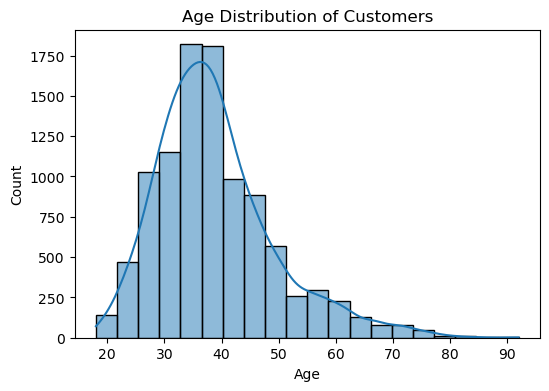

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution of Customers")
plt.show()

**Count Plot of Geography**

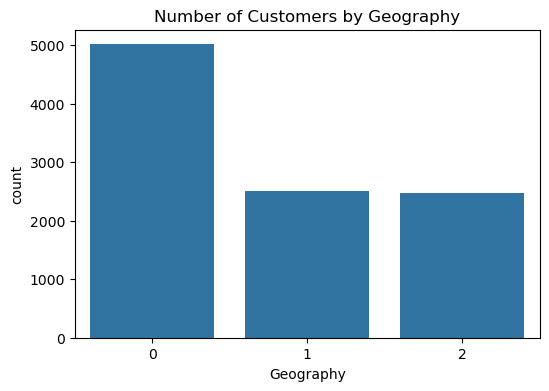

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='Geography', data=df)
plt.title("Number of Customers by Geography")
plt.show()

**Churn by Gender**

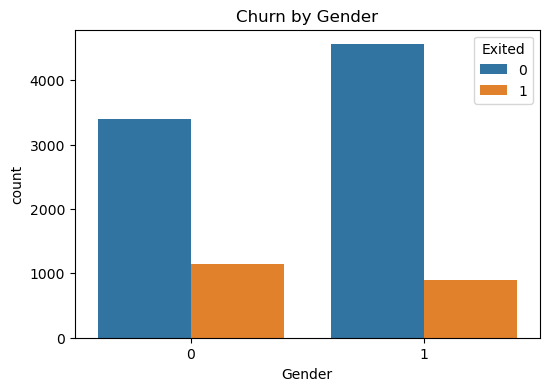

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title("Churn by Gender")
plt.show()

**Model Training and Testing**

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

**Evaluation Metrics**

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8645
Confusion Matrix:
 [[1545   62]
 [ 209  184]]


**Feature Importance**

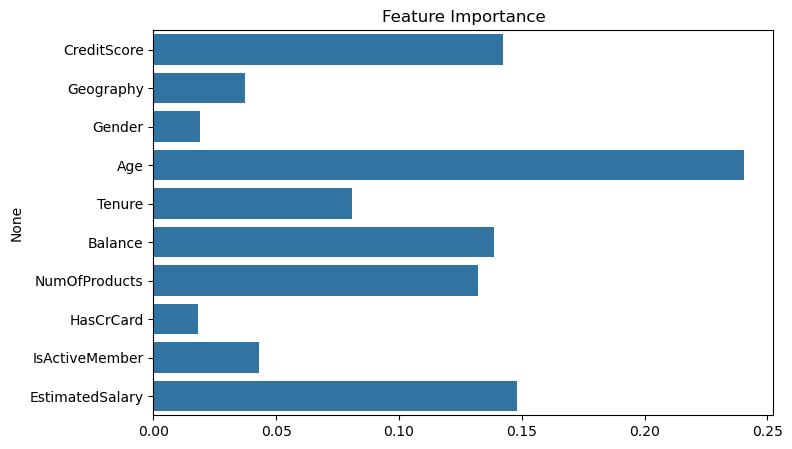

In [9]:
# Feature importance from Random Forest
import numpy as np

importance = model.feature_importances_
features = X.columns

# Plot feature importance
plt.figure(figsize=(8,5))
sns.barplot(x=importance, y=features)
plt.title("Feature Importance")
plt.show()

**Conclusion**

Customer churn can be predicted using financial and demographic data.

Random Forest achieved good accuracy and identified key features influencing churn.

Features such as Balance, Geography, and Age are most important.